# HaluEval: Regression Pipeline for Hallucination Probability

Predicts continuous hallucination probability $p_i$ from HaluEval data.
Includes grid search, AdaBoost, binary vs regression comparison,
and cross-dataset generalization to DefAn, MMLU, and TriviaQA.


## Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from hallucination_utils import *
from regression_utils import *
import xgboost as xgb
import shap

print('All imports loaded.')


All imports loaded.


## Configuration

In [2]:
DATA_PATH = './data/halueval_t1.0_n20.jsonl'
OUTPUT_DIR = 'halueval_regression_output'
EMBED_CACHE = 'halueval_embeddings.npy'
SIM_THRESHOLD = 0.85
N_BOOTSTRAP = 2000
RANDOM_SEED = 42
MIN_QUESTIONS_FOR_ANALYSIS = 10
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data, Embed, Extract Features

In [3]:
df = load_dataset('./data/halueval_t1.0_n20.jsonl')
df = add_canonical_domain(df)
print_loading_summary(df)


Dataset:          halueval
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   8984  (89.8%)
  incorrect   :   1006  (10.1%)
  refused     :     10  (0.1%)

Domains (30 unique)  (showing 10 of 30):
  Business
  Business, Food & Beverage
  Business, Hospitality, Entertainment
  Business, Industry, and Miscellaneous
  Business, Law, and Miscellaneous
  Business, Miscellaneous
  Business, Non-profit
  Business, Social Sciences
  Business, Technology
  Business, and Miscellaneous
  ...


In [4]:
all_embeddings = embed_responses(df, cache_path='halueval_embeddings.npy')
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)
feat_df, skipped, skip_det = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv, domain_col='domain_canonical')
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'halueval_features.csv'), index=False)


# Ensure regression target column exists (backward compat)
ensure_p_halluc(feat_df)

Loading cached embeddings from halueval_embeddings.npy
Correct responses for reference: 8984
Reference fitted. mu shape: (384,), precision shape: (384, 384)
  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 464
  Hallucinated (1): 36
  Rate: 7.2%


,prompt_id,question,domain_canonical,domain_inconsistent,adversarial,n_samples,n_correct,n_incorrect,n_refused,n_definitive,...,score_mean,score_std,len_mean,len_std,H_sem,D_cos,M_bar,K,sig2_S,label
0,halueval_00000_t1.0,Context: He also played non-league football f...,Sports,True,False,20,18,2,0,20,...,4.7,0.900000,56.55,110.319298,2.080482e+00,0.118261,21.027288,7,0.034709,0
1,halueval_00001_t1.0,Context: Janggi (including romanizations chang...,STEM,False,False,20,20,0,0,20,...,5.0,0.000000,6.15,0.357071,-1.442823e-12,0.002990,16.998920,1,0.000108,0
2,halueval_00002_t1.0,"Context: Jang Hoon (born May 4, 1975) is a Sou...",Humanities,False,False,20,19,1,0,20,...,4.8,0.871780,12.15,5.012734,2.863970e-01,0.044602,16.379431,2,0.075854,0
3,halueval_00003_t1.0,"Context: Mr. Wong, Detective is a 1938 America...",Humanities,False,False,20,20,0,0,20,...,5.0,0.000000,13.05,0.217945,-1.442823e-12,0.000888,16.984457,1,0.000031,0
4,halueval_00004_t1.0,Context: The Many Adventures of Winnie the Poo...,Humanities,False,False,20,14,6,0,20,...,4.1,1.374773,58.05,40.195118,1.977235e+00,0.153164,24.313700,5,0.060144,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,halueval_00495_t1.0,Context: The Last Word is a gin-based prohibit...,Social Sciences,True,False,20,18,2,0,20,...,4.7,0.900000,24.85,38.359191,2.081496e+00,0.129329,21.086123,7,0.042691,0
496,halueval_00496_t1.0,"Context: The house features smooth walls, fla...",Humanities,False,False,20,20,0,0,20,...,5.0,0.000000,5.40,1.113553,-1.442823e-12,0.007062,16.196909,1,0.000444,0
497,halueval_00497_t1.0,Context: Wences Casares is the company’s CEO....,Law & Business,True,False,20,18,2,0,20,...,4.7,0.900000,36.55,75.307022,1.021928e+00,0.079779,21.136248,4,0.071778,0
498,halueval_00498_t1.0,Context: Also featuring in guest roles are Mi...,Humanities,False,False,20,20,0,0,20,...,5.0,0.000000,9.15,0.357071,-1.442823e-12,0.002880,16.255478,1,0.000100,0


## Regression Target EDA

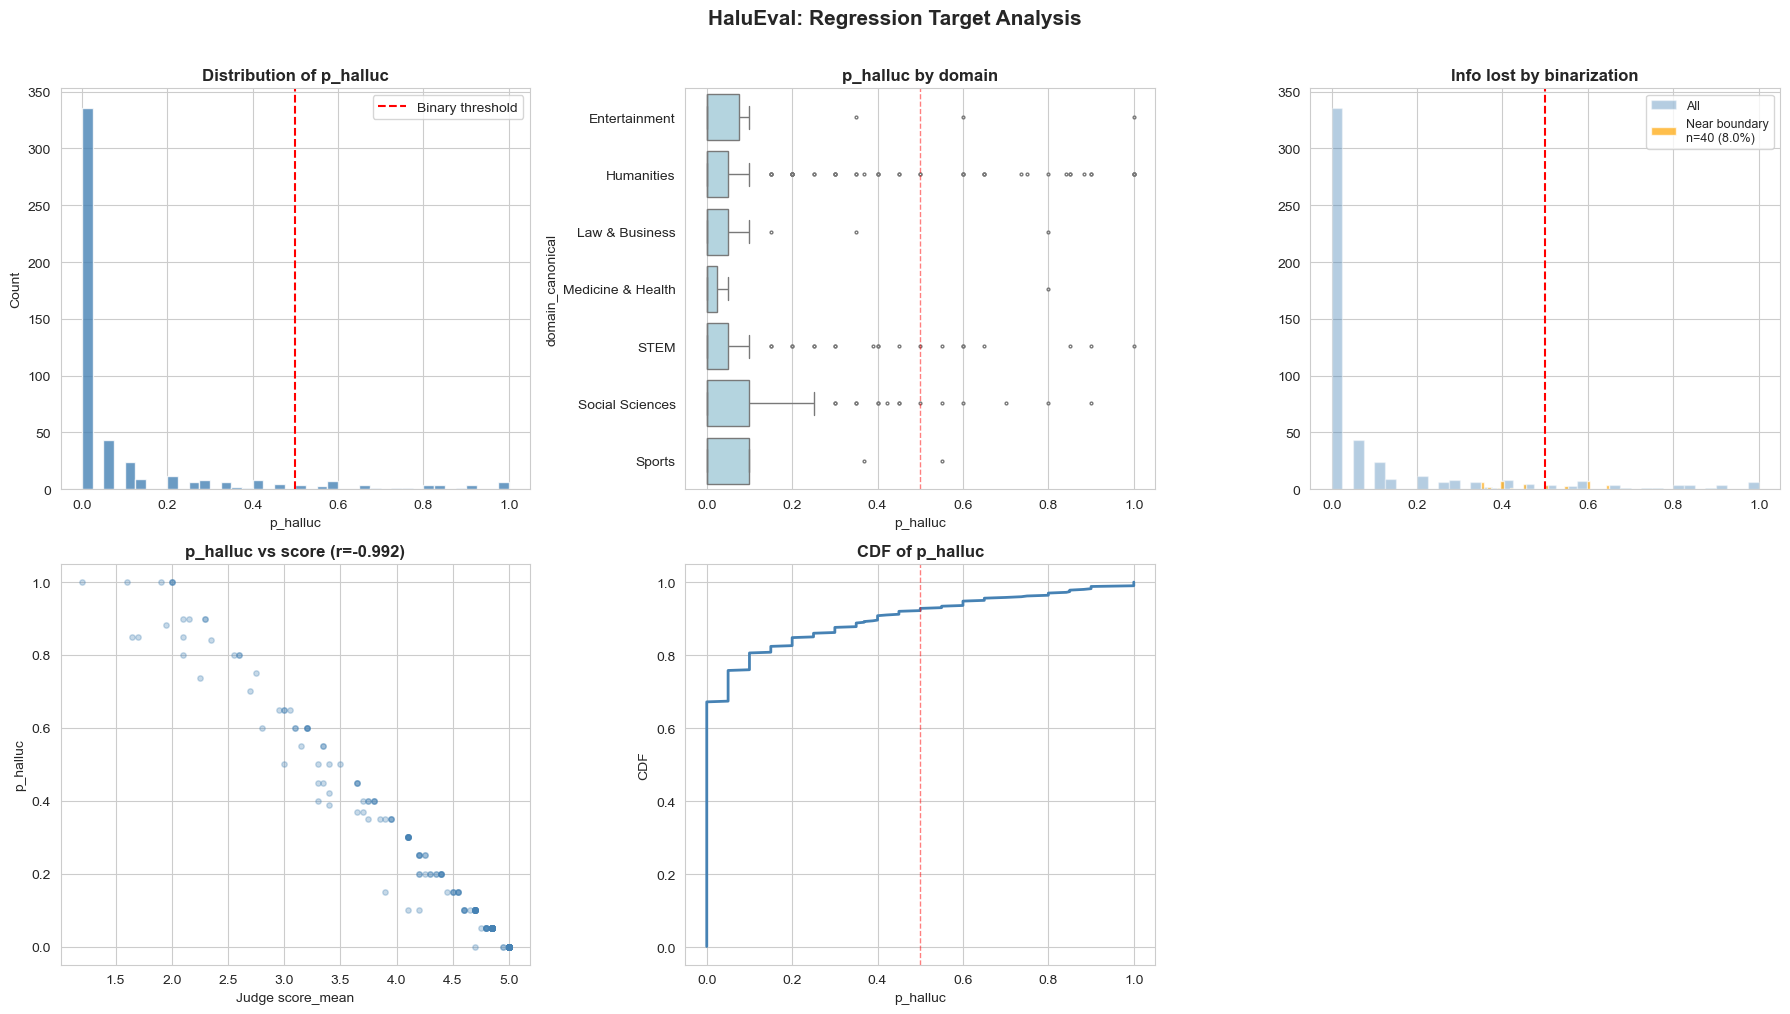

In [5]:
fig = plot_target_eda(feat_df, domain_col='domain_canonical', title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_target_eda.png'), dpi=150, bbox_inches='tight')
plt.show()


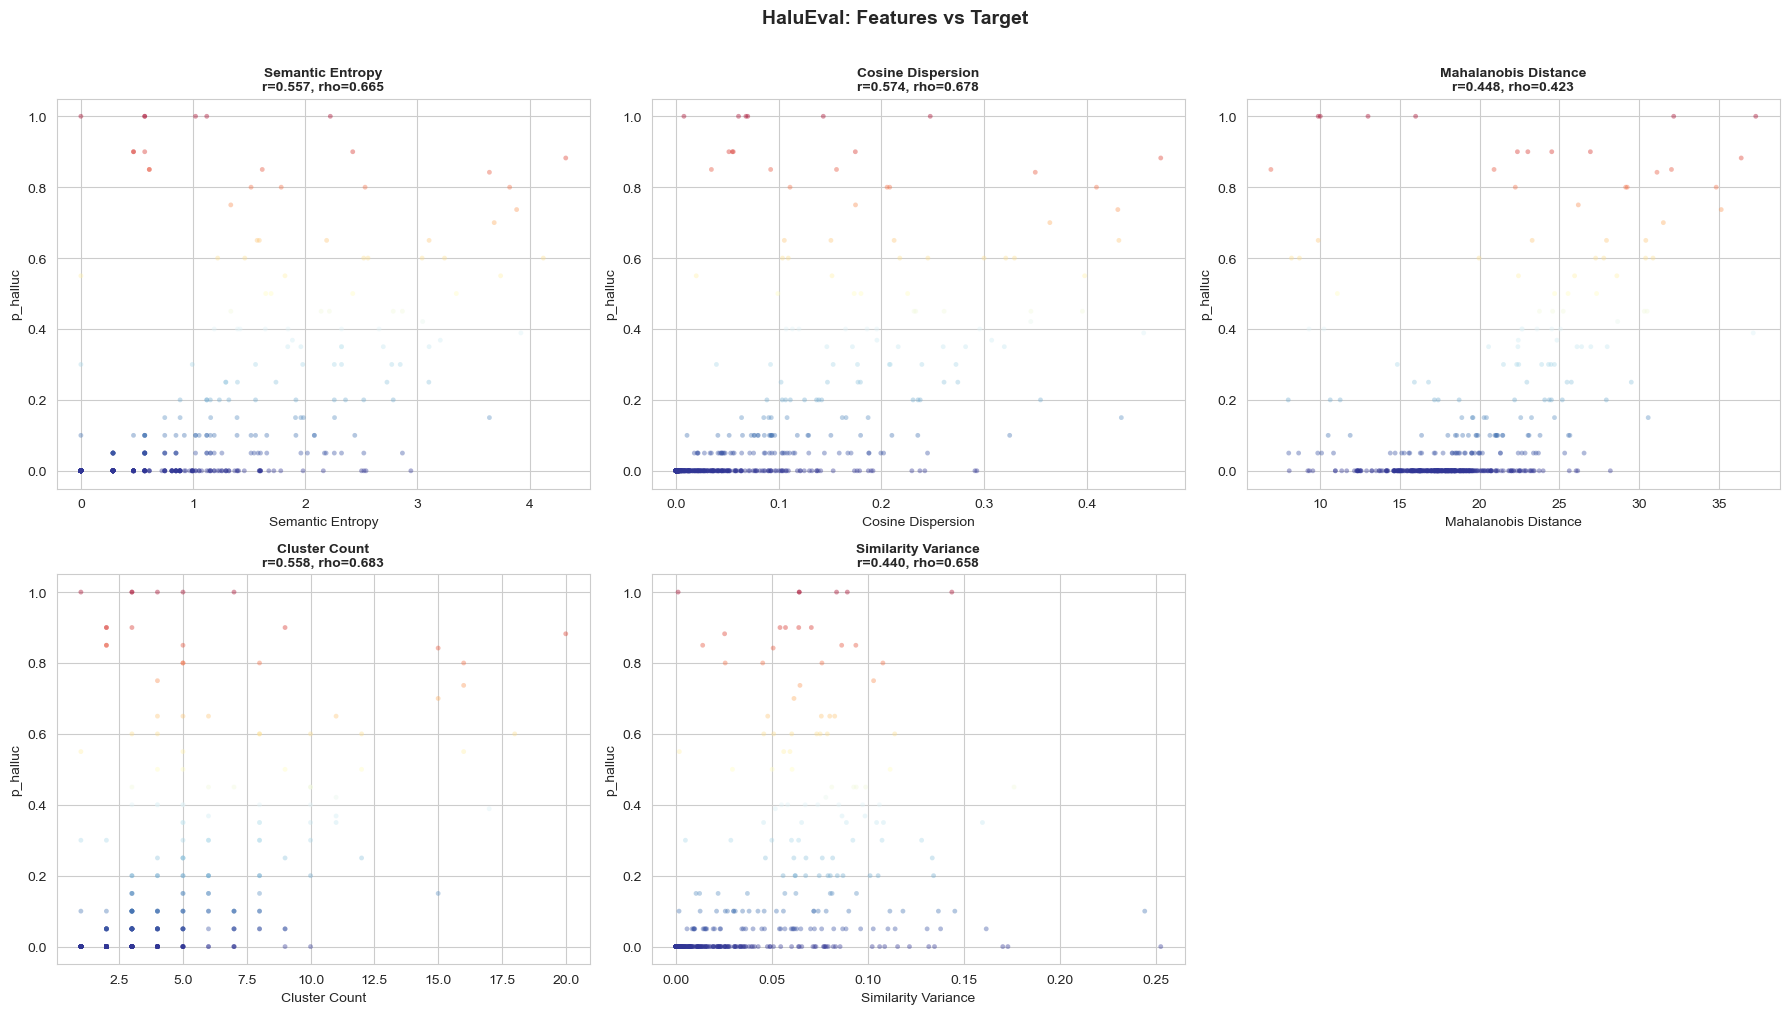

In [6]:
fig = plot_features_vs_target(feat_df, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_features_vs_target.png'), dpi=150, bbox_inches='tight')
plt.show()


## Train / Validation / Test Split

In [7]:
sp = split_train_val_test(feat_df, GEO_FEATURES,
                          test_frac=TEST_FRACTION, val_frac=VAL_FRACTION,
                          seed=RANDOM_SEED)
print_split_summary(sp)


  Train: n= 350  p_halluc mean=0.1077 std=0.2239  binary rate=0.074
  Val  : n=  75  p_halluc mean=0.0923 std=0.1954  binary rate=0.067
  Test : n=  75  p_halluc mean=0.0799 std=0.2059  binary rate=0.067


### Grid Search

We run grid search on models that support it to find optimal hyperparameters
before the main evaluation.


In [8]:
print('Running grid search on training set...')
regressors = get_regressors(seed=RANDOM_SEED)
regressors, df_grid = run_grid_search(regressors, sp['X_train_sc'], sp['y_train_reg'],
                                       seed=RANDOM_SEED, cv_folds=5)
if len(df_grid) > 0:
    display(df_grid)
    df_grid.to_csv(os.path.join(OUTPUT_DIR, 'grid_search_results.csv'), index=False)
print('Grid search complete. Models updated with best params.')


Running grid search on training set...
  Ridge               : searching {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]} ...
    -> best: {'alpha': 100.0}  CV r2=0.2727
  Lasso               : searching {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1]} ...
    -> best: {'alpha': 0.01}  CV r2=0.2480
  ElasticNet          : searching {'alpha': [0.005, 0.01, 0.05, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]} ...
    -> best: {'alpha': 0.1, 'l1_ratio': 0.2}  CV r2=0.2601
  Random Forest       : searching {'n_estimators': [100, 300], 'max_depth': [4, 6, 8]} ...
    -> best: {'max_depth': 4, 'n_estimators': 100}  CV r2=0.3475
  XGBoost             : searching {'n_estimators': [100, 300], 'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.08, 0.1]} ...
    -> best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}  CV r2=0.2757
  SVR (RBF)           : no grid defined, skipping
  AdaBoost            : searching {'n_estimators': [100, 200, 300], 'learning_rate': [0.05, 0.1, 0.3]} ...
    -> best: {'learning_

,Model,Best_Params,Best_CV_Score
0,Ridge,{'alpha': 100.0},0.272660
1,Lasso,{'alpha': 0.01},0.248046
2,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.2}",0.260092
3,Random Forest,"{'max_depth': 4, 'n_estimators': 100}",0.347538
4,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.275724
5,AdaBoost,"{'learning_rate': 0.05, 'n_estimators': 100}",0.310113


Grid search complete. Models updated with best params.


## Regression Models — Evaluation

In [9]:
df_reg, fitted_regs = train_evaluate_regressors(regressors, sp, seed=RANDOM_SEED)
df_reg.to_csv(os.path.join(OUTPUT_DIR, 'regression_results.csv'), index=False)
display(df_reg.round(4))


  Ridge                | CV R²=0.2587  Val R²=0.4003  Test R²=0.5190  Gap=-0.1081
  Lasso                | CV R²=0.2323  Val R²=0.3661  Test R²=0.5177  Gap=-0.0738
  ElasticNet           | CV R²=0.2418  Val R²=0.3535  Test R²=0.4824  Gap=-0.0721
  Random Forest        | CV R²=0.3721  Val R²=0.2251  Test R²=0.5317  Gap=+0.4756
  XGBoost              | CV R²=0.3050  Val R²=0.3263  Test R²=0.5377  Gap=+0.4547
  SVR (RBF)            | CV R²=0.3153  Val R²=0.5633  Test R²=0.5638  Gap=-0.0054
  AdaBoost             | CV R²=0.3365  Val R²=-0.0397  Test R²=0.4443  Gap=+0.7951


,Model,CV_R2,CV_MSE,CV_MAE,Train_R2,Val_R2,Val_MSE,Val_MAE,Test_R2,Test_MSE,Test_MAE,Test_Pearson_r,Overfit_Gap_Val,Overfit_Gap_Test
0,Ridge,0.2587,0.0372,0.1046,0.2922,0.4003,0.0229,0.0867,0.5190,0.0204,0.0775,0.7419,-0.1081,-0.2268
1,Lasso,0.2323,0.0385,0.1066,0.2922,0.3661,0.0242,0.0894,0.5177,0.0204,0.0785,0.7436,-0.0738,-0.2255
2,ElasticNet,0.2418,0.0380,0.1095,0.2814,0.3535,0.0247,0.0943,0.4824,0.0219,0.0864,0.7385,-0.0721,-0.2010
3,Random Forest,0.3721,0.0315,0.0907,0.7006,0.2251,0.0296,0.0954,0.5317,0.0199,0.0616,0.7483,0.4756,0.1689
4,XGBoost,0.3050,0.0348,0.0938,0.7810,0.3263,0.0257,0.0900,0.5377,0.0196,0.0596,0.7490,0.4547,0.2433
5,SVR (RBF),0.3153,0.0343,0.0970,0.5580,0.5633,0.0167,0.0808,0.5638,0.0185,0.0717,0.7769,-0.0054,-0.0058
6,AdaBoost,0.3365,0.0332,0.0902,0.7554,-0.0397,0.0397,0.1007,0.4443,0.0236,0.0661,0.6694,0.7951,0.3112


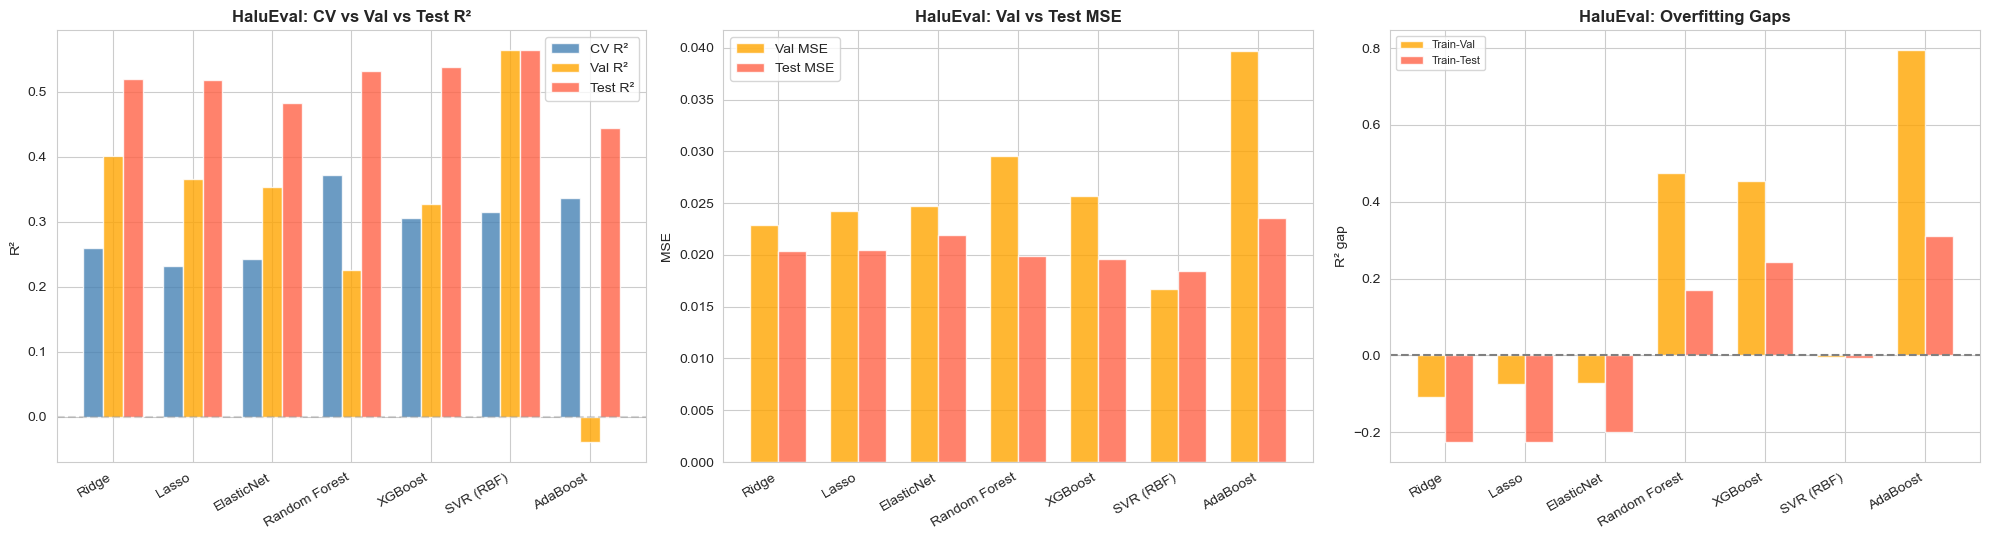

In [10]:
fig = plot_regression_results_bar(df_reg, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_regression_results.png'), dpi=150, bbox_inches='tight')
plt.show()


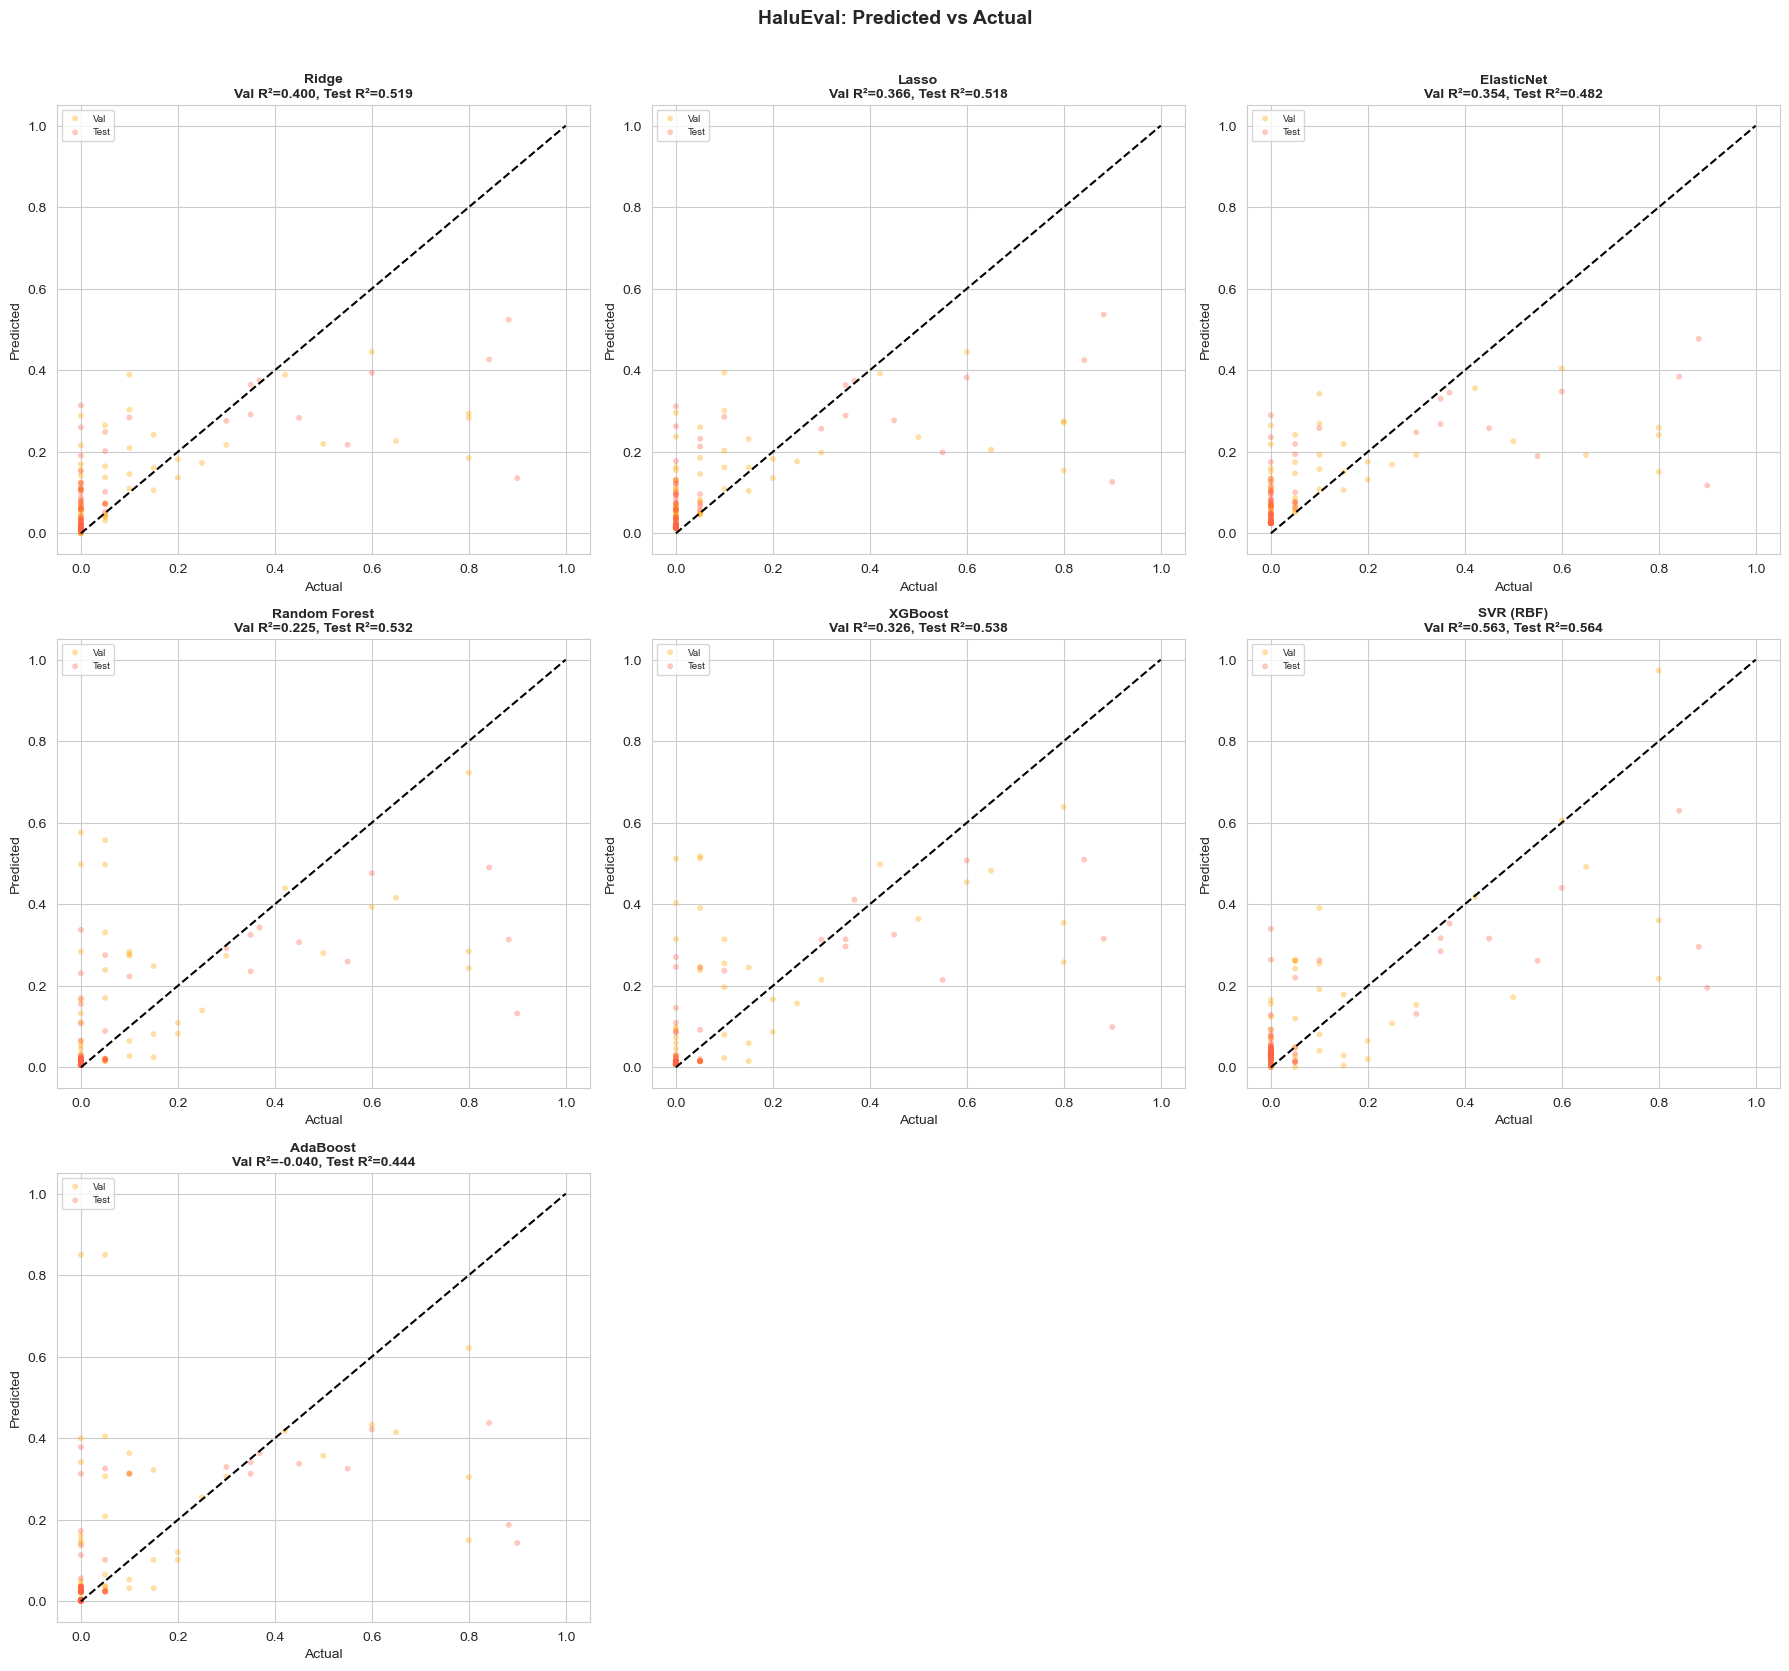

In [11]:
fig = plot_pred_vs_actual(fitted_regs, sp, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()


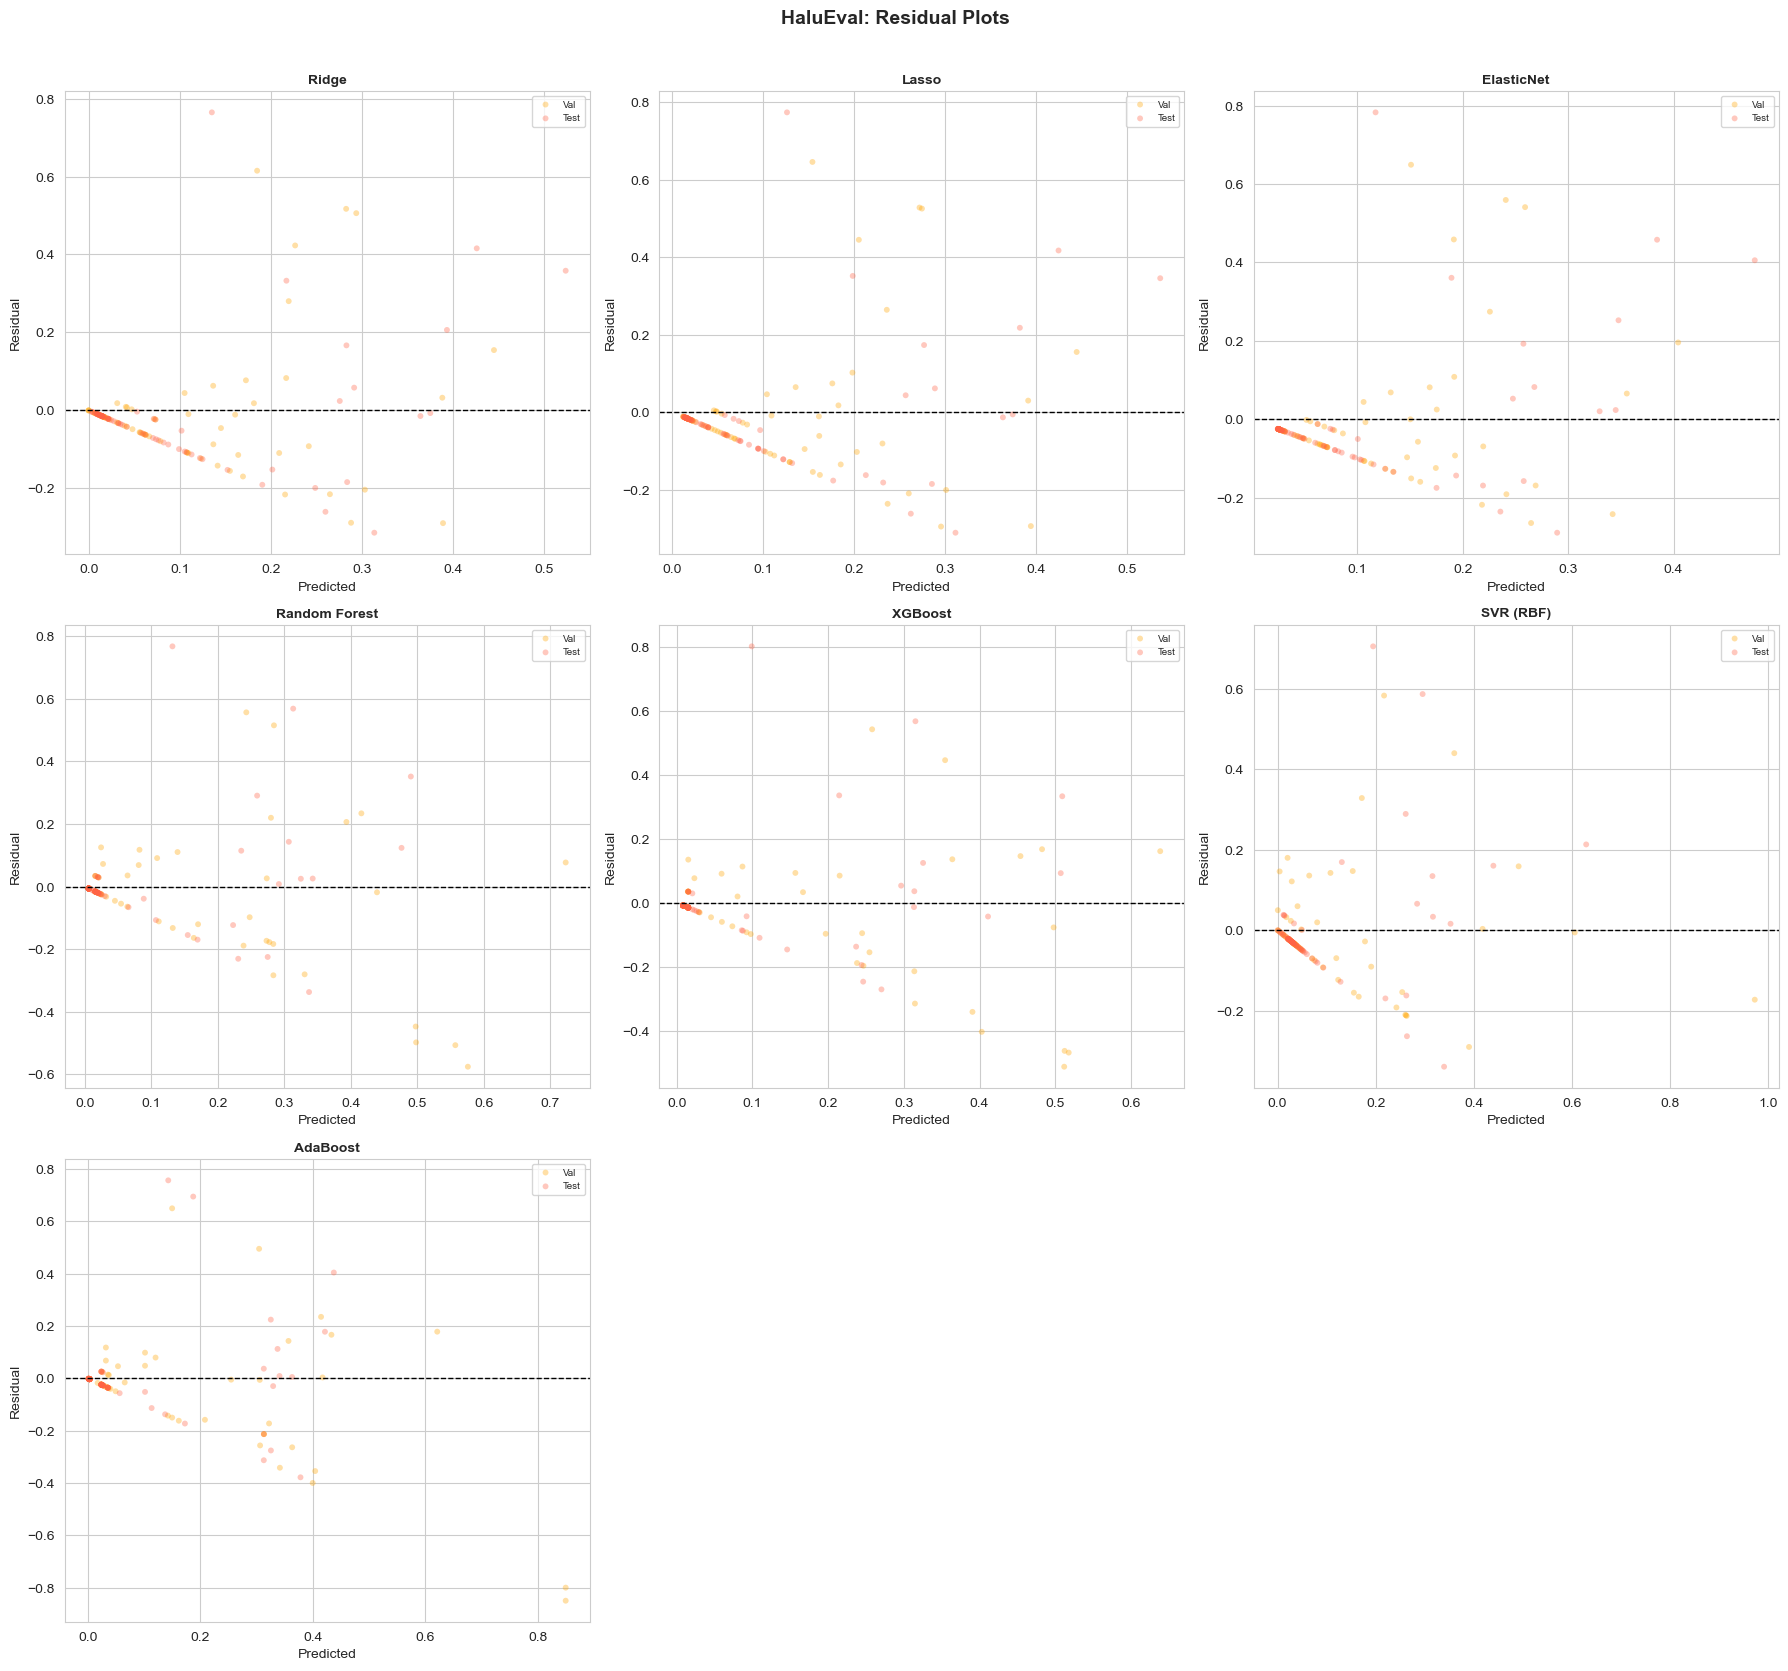

In [12]:
fig = plot_residuals(fitted_regs, sp, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


## Ablation Study (Regression)

Ablation Val R²:


Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,-0.0397,0.2251,0.4003,0.3263
All 5 geometric,-0.0397,0.2251,0.4003,0.3263
Entropy + Geometry,0.1099,0.2717,0.4311,0.1881
Entropy only (H_sem),0.1909,0.3830,0.3768,0.3229
"Geometry (D_cos, M_bar)",0.0896,0.2325,0.4022,0.1979


Ablation Test R²:


Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,0.4443,0.5317,0.5190,0.5377
All 5 geometric,0.4443,0.5317,0.5190,0.5377
Entropy + Geometry,0.4843,0.5552,0.5055,0.5605
Entropy only (H_sem),0.2964,0.4831,0.4372,0.4880
"Geometry (D_cos, M_bar)",0.4779,0.5521,0.4914,0.5365


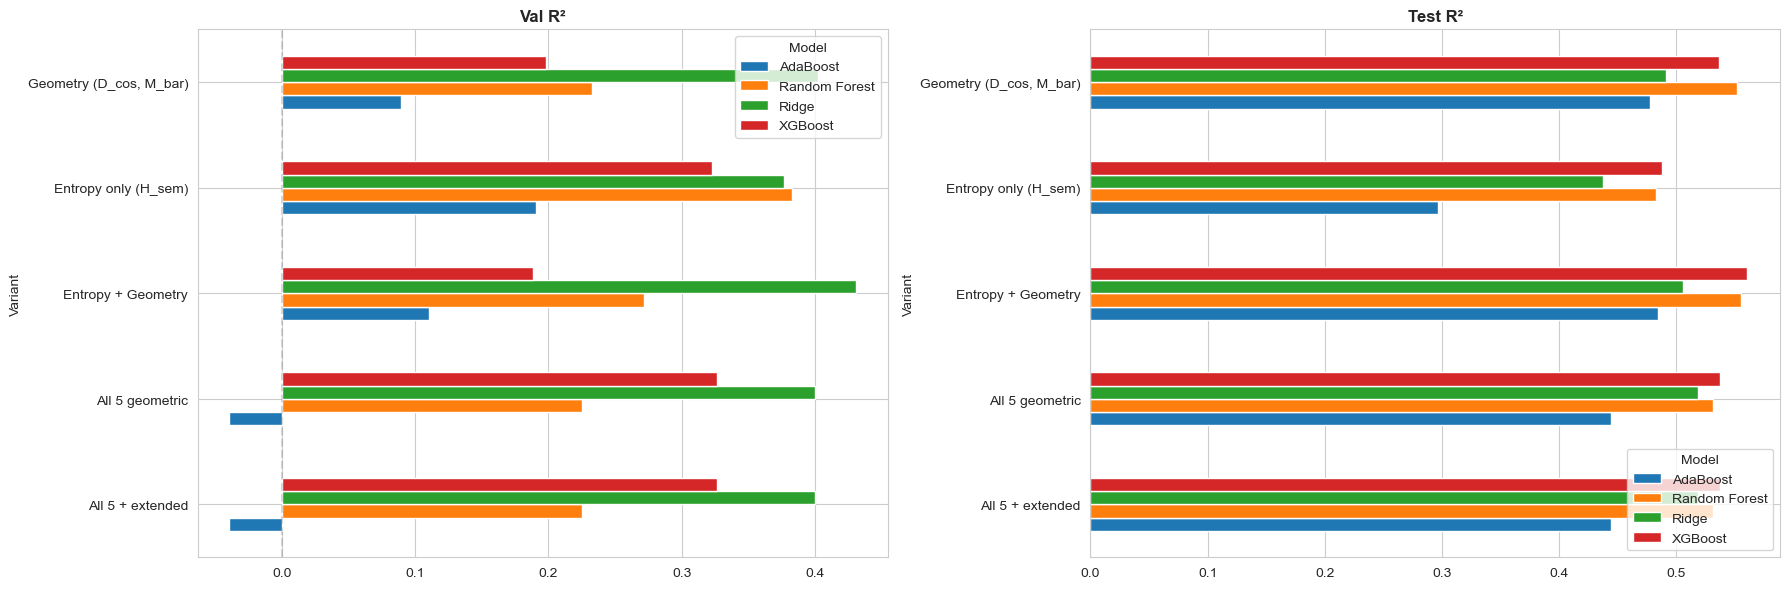

In [13]:
abl_models = {k: regressors[k] for k in ['Ridge', 'Random Forest', 'XGBoost', 'AdaBoost'] if k in regressors}
ext_feats = GEO_FEATURES #+ ['frac_refused', 'score_mean', 'len_mean']
# ensure columns exist
for c in ext_feats:
    if c not in sp['feat_train'].columns:
        ext_feats = GEO_FEATURES  # fallback
        break

df_abl = run_ablation(abl_models, sp, sp['feat_train'], sp['feat_val'], sp['feat_test'],
                       extended_features=ext_feats)
df_abl.to_csv(os.path.join(OUTPUT_DIR, 'ablation_regression.csv'), index=False)

pivot_val = df_abl.pivot_table(index='Variant', columns='Model', values='Val_R2')
pivot_test = df_abl.pivot_table(index='Variant', columns='Model', values='Test_R2')
print('Ablation Val R²:')
display(pivot_val.round(4))
print('Ablation Test R²:')
display(pivot_test.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pivot_val.plot(kind='barh', ax=axes[0]); axes[0].set_title('Val R²', fontweight='bold')
pivot_test.plot(kind='barh', ax=axes[1]); axes[1].set_title('Test R²', fontweight='bold')
for ax in axes: ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


## Ablation Study with 5-Fold Cross-Validation

Re-run the ablation using stratified 5-fold CV over the full
question-level feature set.  This complements the single-split
ablation above with mean ± std estimates that are more robust
to the particular train/val/test partition.

  Entropy only (H_sem)           | Ridge                | R²=0.2955±0.0708  MSE=0.0333±0.0043
  Entropy only (H_sem)           | Random Forest        | R²=0.2636±0.0999  MSE=0.0349±0.0059
  Entropy only (H_sem)           | XGBoost              | R²=0.2493±0.1050  MSE=0.0355±0.0062
  Entropy only (H_sem)           | AdaBoost             | R²=0.1590±0.1264  MSE=0.0398±0.0070
  Geometry (D_cos, M_bar)        | Ridge                | R²=0.3166±0.0847  MSE=0.0324±0.0051
  Geometry (D_cos, M_bar)        | Random Forest        | R²=0.3872±0.1407  MSE=0.0292±0.0077
  Geometry (D_cos, M_bar)        | XGBoost              | R²=0.3634±0.0912  MSE=0.0302±0.0055
  Geometry (D_cos, M_bar)        | AdaBoost             | R²=0.4084±0.1290  MSE=0.0282±0.0069
  Entropy + Geometry             | Ridge                | R²=0.3229±0.0873  MSE=0.0321±0.0052
  Entropy + Geometry             | Random Forest        | R²=0.4215±0.1375  MSE=0.0276±0.0075
  Entropy + Geometry             | XGBoost              | R²

Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,0.4010,0.4118,0.3282,0.3994
All 5 geometric,0.4010,0.4118,0.3282,0.3994
Entropy + Geometry,0.4150,0.4215,0.3229,0.3985
Entropy only (H_sem),0.1590,0.2636,0.2955,0.2493
"Geometry (D_cos, M_bar)",0.4084,0.3872,0.3166,0.3634


Ablation 5-Fold CV R² (std):


Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,0.1042,0.1210,0.0779,0.0959
All 5 geometric,0.1042,0.1210,0.0779,0.0959
Entropy + Geometry,0.1121,0.1375,0.0873,0.0943
Entropy only (H_sem),0.1264,0.0999,0.0708,0.1050
"Geometry (D_cos, M_bar)",0.1290,0.1407,0.0847,0.0912


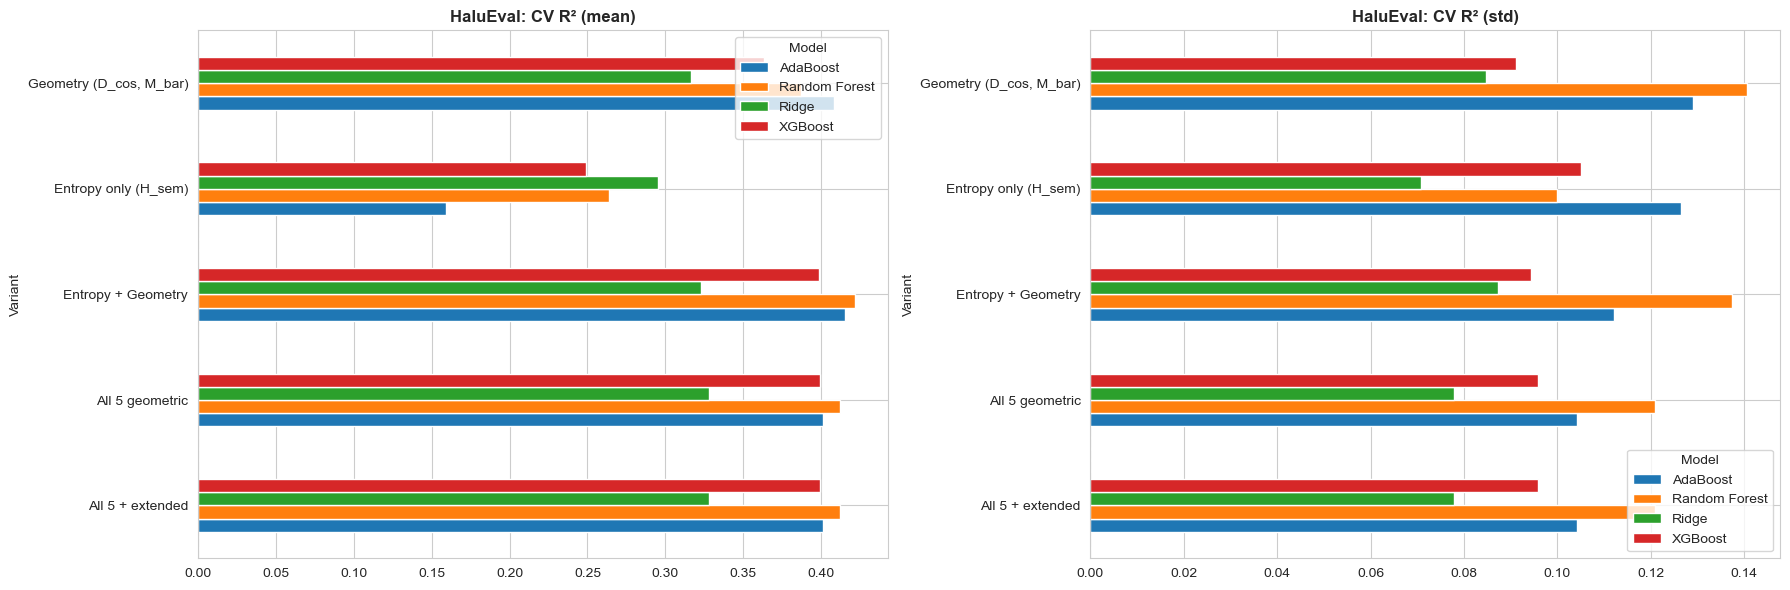

In [14]:
# Re-use the same model subset from the single-split ablation
df_abl_cv = run_ablation_cv(
    abl_models, feat_df,
    target_col='p_halluc',
    geo_features=GEO_FEATURES,
    extended_features=ext_feats,
    n_folds=5,
    seed=RANDOM_SEED,
)
df_abl_cv.to_csv(os.path.join(OUTPUT_DIR, 'ablation_cv.csv'), index=False)

pivot_cv_r2 = df_abl_cv.pivot_table(index='Variant', columns='Model', values='Mean_CV_R2')
pivot_cv_std = df_abl_cv.pivot_table(index='Variant', columns='Model', values='Std_CV_R2')
print('Ablation 5-Fold CV R² (mean):')
display(pivot_cv_r2.round(4))
print('Ablation 5-Fold CV R² (std):')
display(pivot_cv_std.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pivot_cv_r2.plot(kind='barh', ax=axes[0]); axes[0].set_title('HaluEval: CV R² (mean)', fontweight='bold')
pivot_cv_std.plot(kind='barh', ax=axes[1]); axes[1].set_title('HaluEval: CV R² (std)', fontweight='bold')
for ax in axes: ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_ablation_cv.png'), dpi=150, bbox_inches='tight')
plt.show()


#### The 5-fold CV ablation provides a more stable estimate of each feature subset's contribution.  Compare the mean CV R² to the single-split Val/Test R² above — large discrepancies may indicate sensitivity to the particular data partition.

## Binary vs Regression Comparison

Threshold regression predictions at 0.5, compare AUC/Accuracy/F1 against
direct classifiers (including AdaBoost).


In [15]:
classifiers = get_classifiers(seed=RANDOM_SEED)
df_compare = compare_regression_vs_classification(regressors, classifiers, sp)
df_compare.to_csv(os.path.join(OUTPUT_DIR, 'binary_vs_regression.csv'), index=False)

print('=== Val Set ===')
display(df_compare[df_compare['Split']=='Val'].drop(columns='Split').round(4))
print('\n=== Test Set ===')
display(df_compare[df_compare['Split']=='Test'].drop(columns='Split').round(4))


=== Val Set ===


,Model,Approach,AUC,Accuracy,F1
0,Logistic Regression,Classification,0.9029,0.9333,0.0000
2,Random Forest (cls),Classification,0.9371,0.9333,0.2857
4,XGBoost (cls),Classification,0.9029,0.9333,0.4444
6,AdaBoost (cls),Classification,0.8771,0.8933,0.3333
8,Ridge (reg->cls),Regression->Binary,0.9343,0.9333,0.0000
10,Lasso (reg->cls),Regression->Binary,0.9057,0.9333,0.0000
12,ElasticNet (reg->cls),Regression->Binary,0.9000,0.9333,0.0000
14,Random Forest (reg->cls),Regression->Binary,0.9171,0.9200,0.2500
16,XGBoost (reg->cls),Regression->Binary,0.9314,0.9067,0.2222
18,SVR (RBF) (reg->cls),Regression->Binary,0.9743,0.9600,0.5714



=== Test Set ===


,Model,Approach,AUC,Accuracy,F1
1,Logistic Regression,Classification,0.9400,0.9467,0.3333
3,Random Forest (cls),Classification,0.9800,0.9467,0.3333
5,XGBoost (cls),Classification,0.9371,0.9467,0.3333
7,AdaBoost (cls),Classification,0.9143,0.9600,0.5714
9,Ridge (reg->cls),Regression->Binary,0.9400,0.9467,0.3333
11,Lasso (reg->cls),Regression->Binary,0.9371,0.9467,0.3333
13,ElasticNet (reg->cls),Regression->Binary,0.9343,0.9333,0.0000
15,Random Forest (reg->cls),Regression->Binary,0.9429,0.9333,0.0000
17,XGBoost (reg->cls),Regression->Binary,0.9371,0.9600,0.5714
19,SVR (RBF) (reg->cls),Regression->Binary,0.9457,0.9467,0.3333


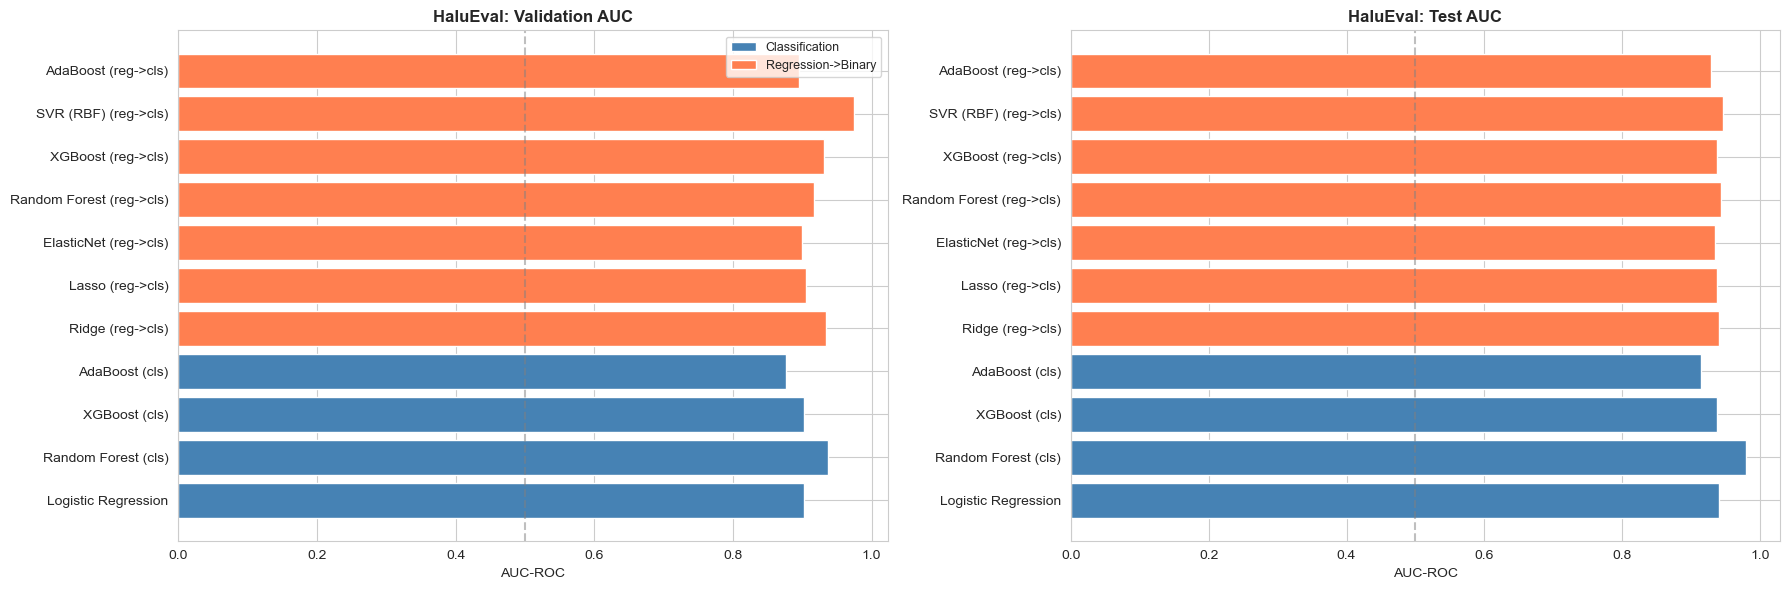

In [16]:
fig = plot_comparison_bar(df_compare, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_cls_vs_reg.png'), dpi=150, bbox_inches='tight')
plt.show()


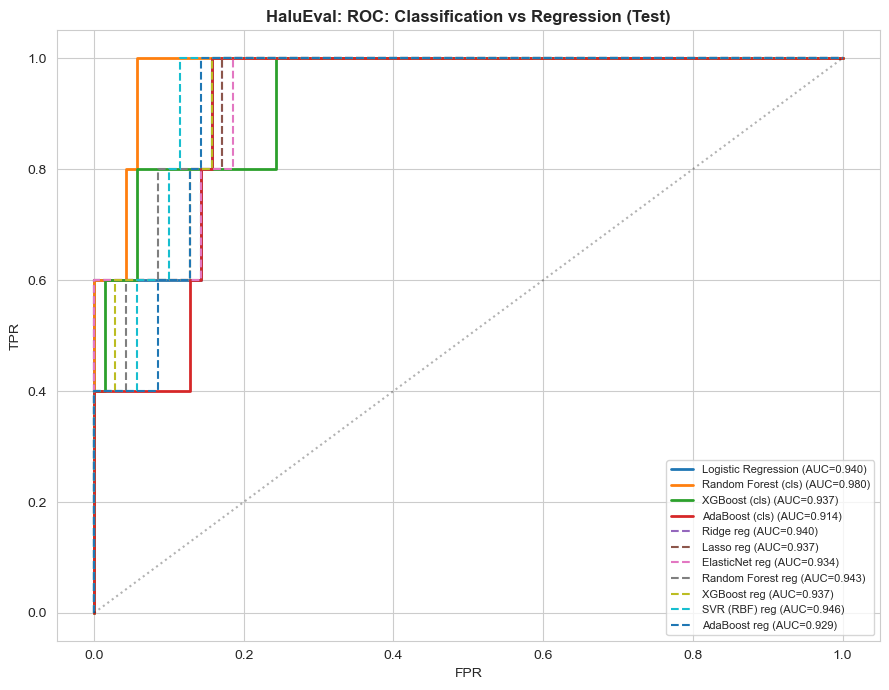

In [17]:
fig = plot_comparison_roc(regressors, classifiers, sp, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


## Bootstrap Confidence Intervals

Best model (by Val R²): SVR (RBF)
  R2: 0.5557  95% CI [0.3301, 0.7871]
  MSE: 0.0187  95% CI [0.0057, 0.0368]
  MAE: 0.0721  95% CI [0.0489, 0.0993]


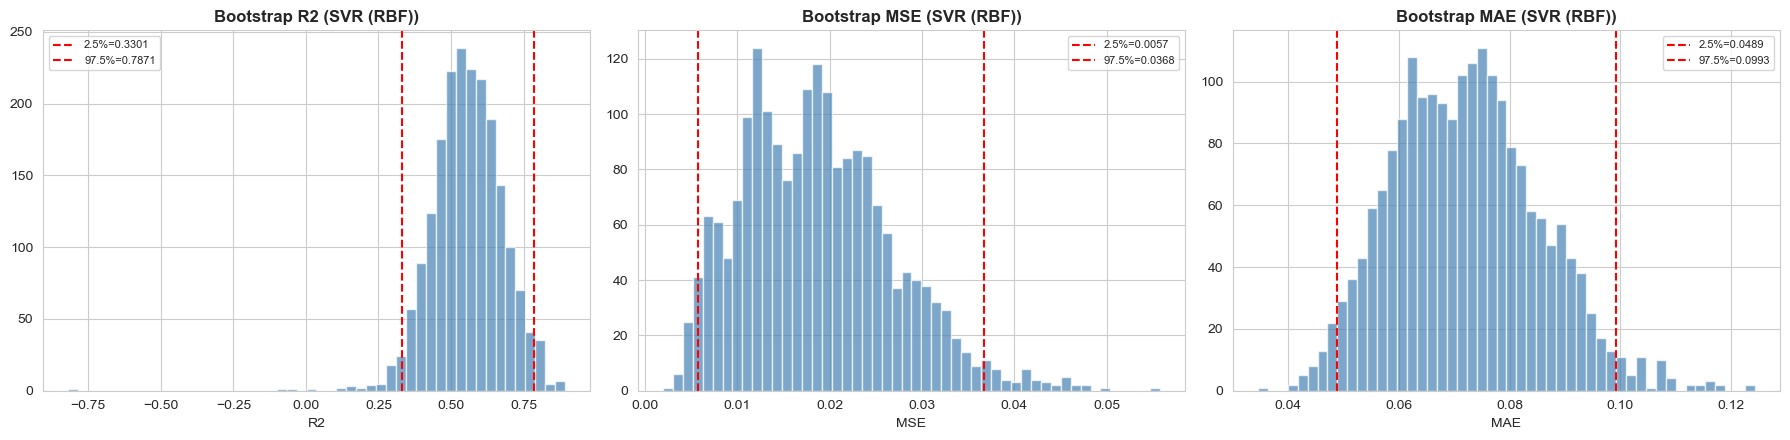

In [18]:
best_name = df_reg.loc[df_reg['Val_R2'].idxmax(), 'Model']
print(f'Best model (by Val R²): {best_name}')
best_reg = fitted_regs[best_name]
best_reg.fit(sp['X_train_sc'], sp['y_train_reg'])
test_preds = np.clip(best_reg.predict(sp['X_test_sc']), 0, 1)

boot = bootstrap_regression_ci(sp['y_test_reg'], test_preds, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED)
for m in ['R2', 'MSE', 'MAE']:
    ci = boot[m]
    print(f'  {m}: {ci["mean"]:.4f}  95% CI [{ci["ci_lo"]:.4f}, {ci["ci_hi"]:.4f}]')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, m in zip(axes, ['R2', 'MSE', 'MAE']):
    vals = boot[m]['values']
    ax.hist(vals, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(boot[m]['ci_lo'], color='red', linestyle='--', label=f'2.5%={boot[m]["ci_lo"]:.4f}')
    ax.axvline(boot[m]['ci_hi'], color='red', linestyle='--', label=f'97.5%={boot[m]["ci_hi"]:.4f}')
    ax.set_xlabel(m); ax.set_title(f'Bootstrap {m} ({best_name})', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_bootstrap_ci.png'), dpi=150, bbox_inches='tight')
plt.show()


## Calibration Analysis

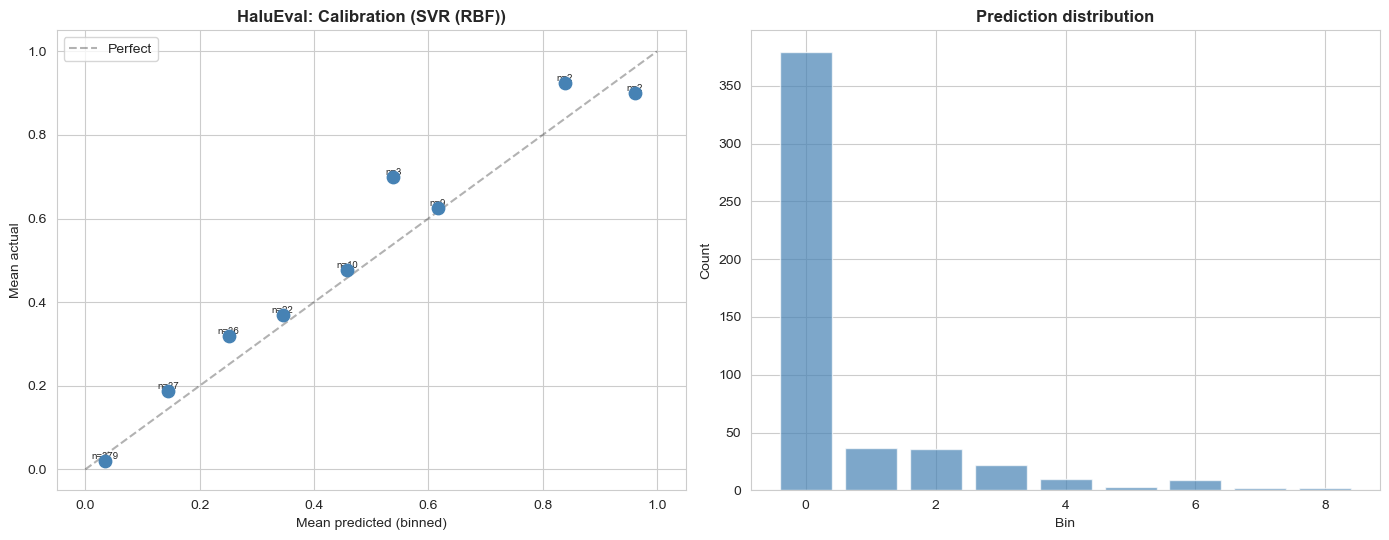

In [19]:
best_name = df_reg.loc[df_reg['Val_R2'].idxmax(), 'Model']
best_reg = fitted_regs[best_name]
sc_cal = StandardScaler().fit(sp['X_train'])
best_reg.fit(sc_cal.transform(sp['X_train']), sp['y_train_reg'])
X_all = feat_df[GEO_FEATURES].values
all_preds = np.clip(best_reg.predict(sc_cal.transform(X_all)), 0, 1)
y_all = feat_df['p_halluc'].values

fig = plot_calibration(y_all, all_preds, model_name=best_name, title_prefix='HaluEval: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()


## Learning Curves

In [20]:
# lc_models = {k: regressors[k] for k in ['Ridge', 'Random Forest', 'XGBoost'] if k in regressors}
# fig = plot_learning_curves(lc_models, sp, title_prefix='HaluEval: ')
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig_learning_curves.png'), dpi=150, bbox_inches='tight')
# plt.show()


## Feature Importance + SHAP

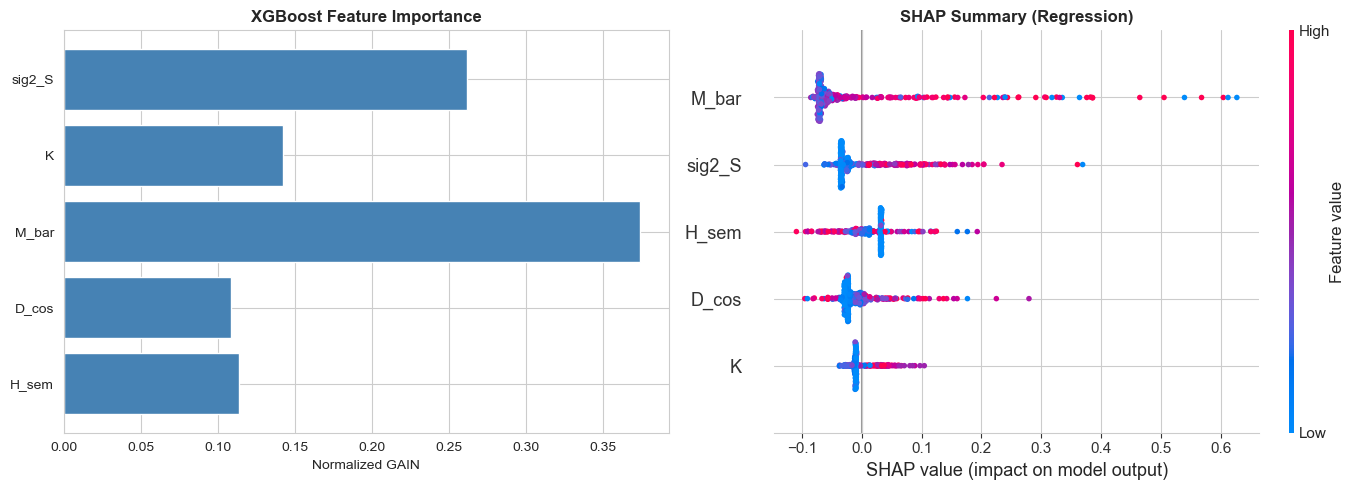

In [21]:
xgb_reg = xgb.XGBRegressor(n_estimators=350, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=RANDOM_SEED, verbosity=0)
xgb_reg.fit(sp['X_train_sc'], sp['y_train_reg'])

explainer = shap.TreeExplainer(xgb_reg)
sv = explainer.shap_values(sp['X_train_sc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
booster = xgb_reg.get_booster()
gain_dict = booster.get_score(importance_type='gain')
gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(len(GEO_FEATURES))], dtype=float)
total = gains.sum()
gains_norm = gains / total if total > 0 else gains
axes[0].barh(GEO_FEATURES, gains_norm, color='steelblue')
axes[0].set_xlabel('Normalized GAIN'); axes[0].set_title('XGBoost Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, sp['X_train_sc'], feature_names=GEO_FEATURES, show=False, plot_size=None)
axes[1].set_title('SHAP Summary (Regression)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cross-Dataset Generalization

Train on HaluEval, predict on: DefAn, MMLU, TriviaQA.
Both regression and classification models are compared.


### HaluEval → DefAn

DefAn loaded: 500 questions, label rate=0.796


,Model,Approach,DefAn_AUC,DefAn_Acc,DefAn_F1,DefAn_R2
0,Ridge,Regression,0.8669,0.364,0.3347,-1.4668
1,Lasso,Regression,0.8481,0.292,0.1991,-1.6478
2,ElasticNet,Regression,0.8459,0.204,0.0000,-1.9309
3,Random Forest,Regression,0.7537,0.460,0.5073,-1.5074
4,XGBoost,Regression,0.7691,0.492,0.5559,-1.3203
5,SVR (RBF),Regression,0.7413,0.368,0.3655,-1.6507
6,AdaBoost,Regression,0.6959,0.364,0.3589,-2.0678
7,Logistic Regression,Classification,0.8514,0.352,0.3136,NaN
8,Random Forest (cls),Classification,0.7886,0.534,0.5990,NaN
9,XGBoost (cls),Classification,0.7193,0.322,0.2863,NaN


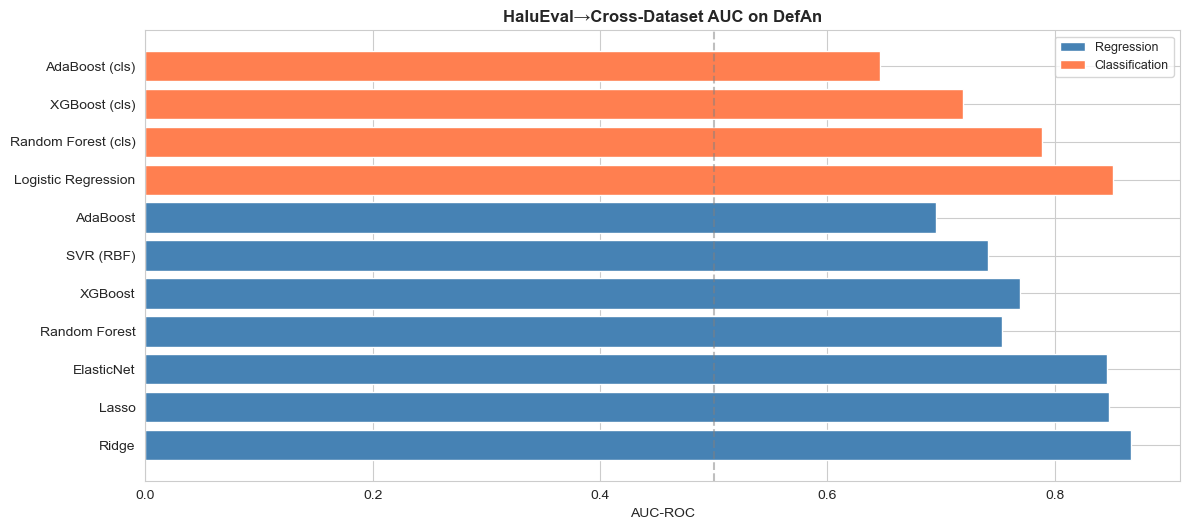

In [22]:
# Load target features
tgt_path = 'defan_regression_output/defan_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'DefAn loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'DefAn')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_defan.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'DefAn', title_prefix='HaluEval→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_defan.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the DefAn classification pipeline first.')


### HaluEval → MMLU

MMLU loaded: 500 questions, label rate=0.784


,Model,Approach,MMLU_AUC,MMLU_Acc,MMLU_F1,MMLU_R2
0,Ridge,Regression,0.7482,0.216,0.0000,-2.4812
1,Lasso,Regression,0.7240,0.216,0.0000,-2.5887
2,ElasticNet,Regression,0.7184,0.216,0.0000,-2.9136
3,Random Forest,Regression,0.6839,0.216,0.0000,-5.9561
4,XGBoost,Regression,0.6614,0.218,0.0051,-4.1280
5,SVR (RBF),Regression,0.6342,0.598,0.6996,-0.9913
6,AdaBoost,Regression,0.6799,0.216,0.0000,-6.8901
7,Logistic Regression,Classification,0.7236,0.306,0.2202,NaN
8,Random Forest (cls),Classification,0.6035,0.232,0.0448,NaN
9,XGBoost (cls),Classification,0.6256,0.242,0.0688,NaN


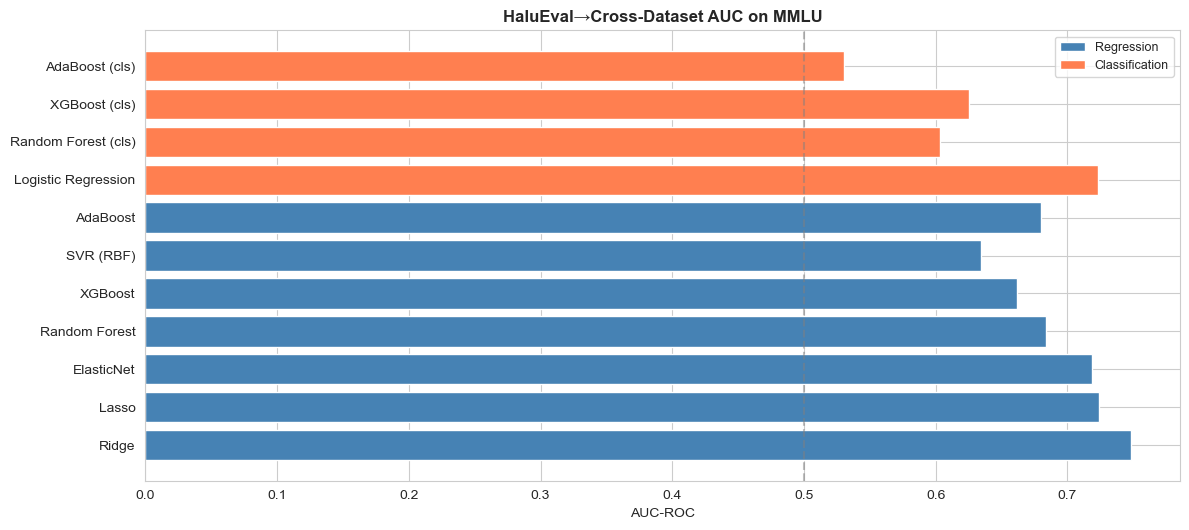

In [23]:
# Load target features
tgt_path = 'mmlu_output/mmlu_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'MMLU loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'MMLU')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_mmlu.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'MMLU', title_prefix='HaluEval→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_mmlu.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the MMLU classification pipeline first.')


### HaluEval → TriviaQA

TriviaQA loaded: 500 questions, label rate=0.416


,Model,Approach,TriviaQA_AUC,TriviaQA_Acc,TriviaQA_F1,TriviaQA_R2
0,Ridge,Regression,0.9290,0.610,0.1176,0.2030
1,Lasso,Regression,0.9159,0.610,0.1176,0.1594
2,ElasticNet,Regression,0.9131,0.588,0.0190,0.0752
3,Random Forest,Regression,0.9546,0.744,0.5789,0.4316
4,XGBoost,Regression,0.9576,0.790,0.6809,0.4899
5,SVR (RBF),Regression,0.9594,0.824,0.7427,0.5319
6,AdaBoost,Regression,0.9137,0.680,0.3939,0.2495
7,Logistic Regression,Classification,0.9130,0.610,0.1176,NaN
8,Random Forest (cls),Classification,0.9557,0.786,0.6646,NaN
9,XGBoost (cls),Classification,0.9445,0.678,0.3878,NaN


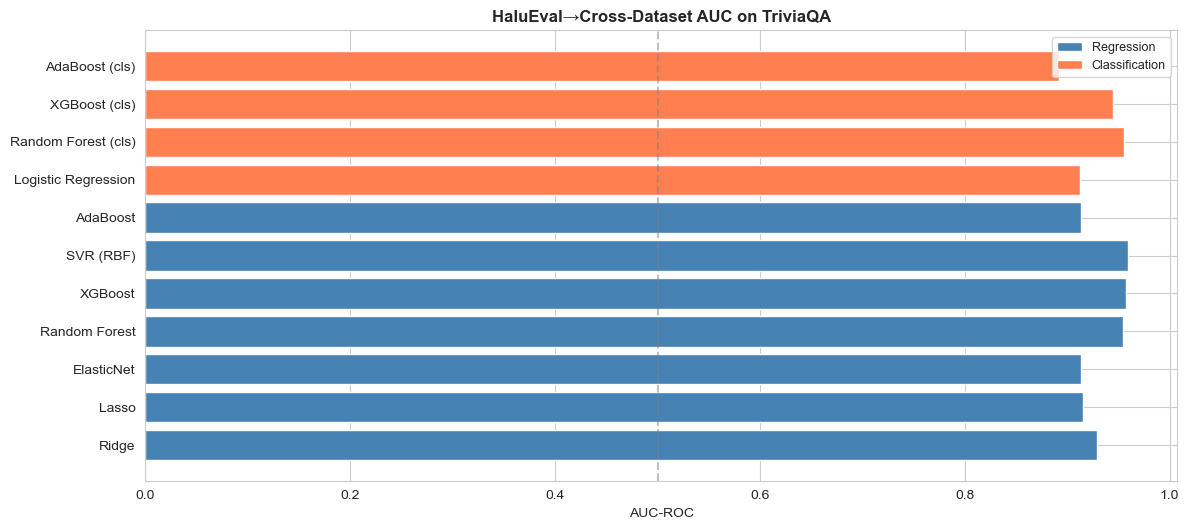

In [24]:
# Load target features
tgt_path = 'triviaqa_output/triviaqa_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'TriviaQA loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'TriviaQA')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_triviaqa.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'TriviaQA', title_prefix='HaluEval→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_triviaqa.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the TriviaQA classification pipeline first.')


## Summary

In [25]:
print('=' * 76)
print('HALUEVAL REGRESSION PIPELINE SUMMARY')
print('=' * 76)
print(f'Questions analyzed: {len(feat_df)}')
print(f'Split: Train={len(sp["X_train"])} / Val={len(sp["X_val"])} / Test={len(sp["X_test"])}')
print(f'Target p_halluc: mean={feat_df["p_halluc"].mean():.4f}, std={feat_df["p_halluc"].std():.4f}')
print()

best = df_reg.loc[df_reg['Val_R2'].idxmax()]
print(f'Best regression model (by Val R²): {best["Model"]}')
print(f'  CV R²={best["CV_R2"]:.4f}  Val R²={best["Val_R2"]:.4f}  Test R²={best["Test_R2"]:.4f}')
print(f'  Overfit gap: {best["Overfit_Gap_Val"]:+.4f}')
print()

best_clf = df_compare[df_compare['Split']=='Test'].sort_values('AUC', ascending=False).iloc[0]
print(f'Best binary model (Test AUC): {best_clf["Model"]} ({best_clf["Approach"]})')
print(f'  AUC={best_clf["AUC"]:.4f}  Acc={best_clf["Accuracy"]:.4f}  F1={best_clf["F1"]:.4f}')
print()

print('Cross-dataset targets: DefAn, MMLU, TriviaQA')
print(f'Outputs: {OUTPUT_DIR}/')
print('=' * 76)


HALUEVAL REGRESSION PIPELINE SUMMARY
Questions analyzed: 500
Split: Train=350 / Val=75 / Test=75
Target p_halluc: mean=0.1012, std=0.2176

Best regression model (by Val R²): SVR (RBF)
  CV R²=0.3153  Val R²=0.5633  Test R²=0.5638
  Overfit gap: -0.0054

Best binary model (Test AUC): Random Forest (cls) (Classification)
  AUC=0.9800  Acc=0.9467  F1=0.3333

Cross-dataset targets: DefAn, MMLU, TriviaQA
Outputs: halueval_regression_output/
